In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ase.io import read
import matplotlib.pylab as pylab
from ase.units import kB
from flonacomldft.utils.io_utils import save_pickle_file, load_pickle_file, load_csv_file, get_project_path
from flonacomldft.utils.diagnostics import R_hat
import pandas as pd

scale=1
size=18
params = {'legend.fontsize': size,
          'figure.figsize': (14*2, 12*2),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [2]:
# get minima structure configurations
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.utils.plots import plot_energy_surface, plot_energy_histogram
from ase.visualize.plot import plot_atoms
from flonacomldft.internal_coordinates import Coordinates_mapping

# load adaptive simulations
from flonacomldft.utils.io_utils import load_pickle_file
from flonacomldft.utils.plots import set_plot_sequential_data, load_ag6_image
from flonacomldft.utils.diagnostics import avg_windows

In [3]:
# 350 K results
path = "/mnt/home/amolina/ceph/adaptive-350/adaptive-dft"
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = [#'2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                     '2-adaptive-mlp/results_adaptive_is0_29525786/adaptive_sampling_is0_29525786.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

adaptives_dft = {i: load_pickle_file(adaptive_dft_path[i], path) for i in range(0, 2)}
adaptives_mlp = {i: load_pickle_file(adaptive_mlp_path[i], path) for i in range(0, 2)}

In [4]:
def get_info_from_adaptive(adaptive, path, isomer):
    
    accs = torch.cat(adaptive['accs']).mean(axis=1)
    us = torch.cat(adaptive['us'])
    xs = torch.cat(adaptive['xs'])

    cvs = cvs_from_adaptive(adaptive, isomer_id=isomer)

    #part_ratios = compute_part_ratios_per_adaptive(adaptive, path, isomer)

    flow_models = adaptive["dict_flows_training"]

    nlls = []
    for i in range(30):
        nll = []
        for x in adaptive['xs'][i]:
            nll.append(flow_models[i][0]['model'].nll(x))
        nll = torch.stack(nll)
        nlls.append(nll)

    to_return = {
        'accs' : accs,
        'us' : us,
        'nlls' : nlls,
        #'part_ratios' : part_ratios,
        'cvs' : cvs,
    }

    return to_return

In [5]:
keys = ['ab-flowMC w.o NP', 'ab-flowMC', 'MD']
color_keys = dict(zip(keys, ['blue', 'orange', 'green']))

In [6]:
adaptives_is0 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys, [adaptive_dft_path[0], adaptive_mlp_path[0]])}
adaptives_is1 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys, [adaptive_dft_path[1], adaptive_mlp_path[1]])}

In [7]:
adaptive_path_is0 = {keys[0]: adaptive_dft_path[0],
                     keys[1]: adaptive_mlp_path[0]}

adaptive_path_is1 = {keys[0]: adaptive_dft_path[1],
                     keys[1]: adaptive_mlp_path[1]}

In [8]:
is0_md = load_csv_file('is0_flow_train.csv', get_project_path() + '/database/andersen/datasets')
is1_md = load_csv_file('is1_flow_train.csv', get_project_path() + '/database/andersen/datasets')

In [9]:
save_plot_data = "data_for_plots"

adaptive_info_is0 = load_pickle_file('ab-initio-flow-is0.pkl', get_project_path() + '/' + save_plot_data)
adaptive_info_is1 = load_pickle_file('ab-initio-flow-is1.pkl', get_project_path() + '/' + save_plot_data)

import copy

for i, key in enumerate(copy.deepcopy(adaptive_info_is0).keys()):
    adaptive_info_is0[keys[i]] = adaptive_info_is0[key]
    del adaptive_info_is0[key]

for i, key in enumerate(copy.deepcopy(adaptive_info_is1).keys()):
    adaptive_info_is1[keys[i]] = adaptive_info_is1[key]
    del adaptive_info_is1[key]

In [10]:
plot_data_is0 = {
    'isomer' : 0,
    'keys' : keys,
    'accs' : {key: adaptive_info_is0[key]['accs'] for key in keys if key != 'MD'},
    'us' : {key: adaptive_info_is0[key]['us'] for key in keys if key != 'MD'},
    'nlls' : {key: torch.cat(adaptive_info_is0[key]['nlls']) for key in keys if key != 'MD'},
    #'part_ratios' : {key: adaptive_info_is0[key]['part_ratios'] for key in keys},
    'energies' : {key: adaptive_info_is0[key]['us'].flatten().detach().numpy() for key in keys if key != 'MD'},
    'cvs' : {key: adaptive_info_is0[key]['cvs'] for key in keys if key != 'MD'},
    'rhat' : {key: R_hat(torch.cat((adaptive_info_is0[key]['cvs'].reshape(600, 50, 2), adaptive_info_is0[key]['us'].reshape(600, 50, 1)), dim=2).detach().numpy().transpose(1, 0, 2), 
                    labels=['Coordination number', 'Radius of gyration', 'Energy']) for key in keys if key != 'MD'}
}

plot_data_is0['cvs']['MD'] = is0_md[:, -2:]
plot_data_is0['energies']['MD'] = is0_md[:, 12]

In [11]:
plot_data_is1 = {
    'isomer' : 1,
    'keys' : keys,
    'accs' : {key: adaptive_info_is1[key]['accs'] for key in keys if key != 'MD'},
    'us' : {key: adaptive_info_is1[key]['us'] for key in keys if key != 'MD'},
    'nlls' : {key: torch.cat(adaptive_info_is1[key]['nlls']) for key in keys if key != 'MD'},
    #'part_ratios' : {key: adaptive_info_is1[key]['part_ratios'] for key in keys},
    'energies' : {key: adaptive_info_is1[key]['us'].flatten().detach().numpy() for key in keys if key != 'MD'},
    'cvs' : {key: adaptive_info_is1[key]['cvs'] for key in keys if key != 'MD'},
    'rhat' : {key: R_hat(torch.cat((adaptive_info_is1[key]['cvs'].reshape(600, 50, 2), adaptive_info_is1[key]['us'].reshape(600, 50, 1)), dim=2).detach().numpy().transpose(1, 0, 2),
                    labels=['Coordination number', 'Radius of gyration', 'Energy']) for key in keys if key != 'MD'}
}

plot_data_is1['cvs']['MD'] = is1_md[:, -2:]
plot_data_is1['energies']['MD'] = is1_md[:, 12]

In [12]:
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter

In [13]:

def plot_figure_single_isomer_slide(plot_data, colors, scale=scale):
    formatter = FormatStrFormatter('%.1f')

    keys = plot_data['keys']
    
    fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(16, 13))#, gridspec_kw={'width_ratios': [1.6, 1, 1]})
    
    #==== PLOT CVS
    
    for key in plot_data['cvs'].keys() :
        axs[0, 0].scatter(plot_data['cvs'][key][:, 0].detach().numpy(), 
                        plot_data['cvs'][key][:, 1].detach().numpy(), 
                        c=colors[key], 
                        s=5*scale,
                        label=key)

    axs[0, 0].set_xlabel('Coordination number')
    axs[0, 0].set_ylabel('Radius of gyration')

    axs[0, 0].legend(loc='upper right')
    
    #==== PLOT Isomer image

    l, b, h, w = 0.15, 0.55, .15, .075
    ax2 = fig.add_axes([l, b, w, h])
    ax2.imshow(load_ag6_image(plot_data['isomer']))
    ax2.set_xticks([])
    ax2.set_yticks([])

    #==== PLOT energies histogram
    #sns.histplot(config['data'], label=label, color=config['color'], alpha=0.5)

    plot_energy_histogram(plot_data['energies'], 
                        ax=axs[0][1], 
                        bins=20, 
                        alpha=0.2, 
                        #hue_order=list(plot_data['energies'].keys())[::-1],
                        palette=colors,
                        element='step',
                        legend=True,
                        )
    axs[0][1].set_xlabel("Potential energy [e.V]")

    #==== PLOT acceptance ratio 

    for key in plot_data['accs'].keys():
        set_plot_sequential_data(plot_data['accs'][key], 
                             avg=True, 
                             window_size=25, 
                             color=colors[key], 
                             ax=axs[1][0], 
                             linewidth=2*scale, 
                             alpha=0.1,
                             label=key)

    #axs[1][1].legend()
    axs[1][0].set_ylabel("Acceptance ratio")
    axs[1][0].set_xlabel("MCMC steps")
    axs[1][0].legend()

    #===== PLOT RHAT

    markers = ['o', 'x', '^']
    linestyles = ['dashed', 'dotted', '-']

    for key in plot_data['rhat'].keys():
        for i in range(plot_data['rhat'][key][0].shape[-1]):
            axs[1][1].plot(plot_data['rhat'][key][1], 
                            plot_data['rhat'][key][0][:, i], 
                            linestyle=linestyles[i], 
                            marker=markers[i],
                            markersize=5*scale,
                            linewidth=2*scale,
                            color=colors[key],
                            label=plot_data['rhat'][key][2][i])
        axs[1][1].axhline(1, c='k', ls='--')
        axs[1][1].axhline(1.01, c='grey', ls='--')
        axs[1][1].set_xlabel('Iteration')
        axs[1][1].set_ylabel(r'$\hat{R}$')

    colors = ["k"]*3
    patches = [ axs[1][1].plot([],[], marker=markers[i], linestyle=linestyles[i], linewidth=2*scale, markersize=5*scale, color=colors[i], 
                label="{:s}".format(plot_data['rhat'][key][2][i]) )[0]  for i in range(len(plot_data['rhat'][key][2])) ]
    axs[1][1].legend(handles=patches)#, bbox_to_anchor=(0.5, 0.5), 
           #loc='center', ncol=2, facecolor="plum", numpoints=1 )

    for ax in axs.ravel():
        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))
        ax.xaxis.set_major_formatter(formatter)
        ax.yaxis.set_major_formatter(formatter)

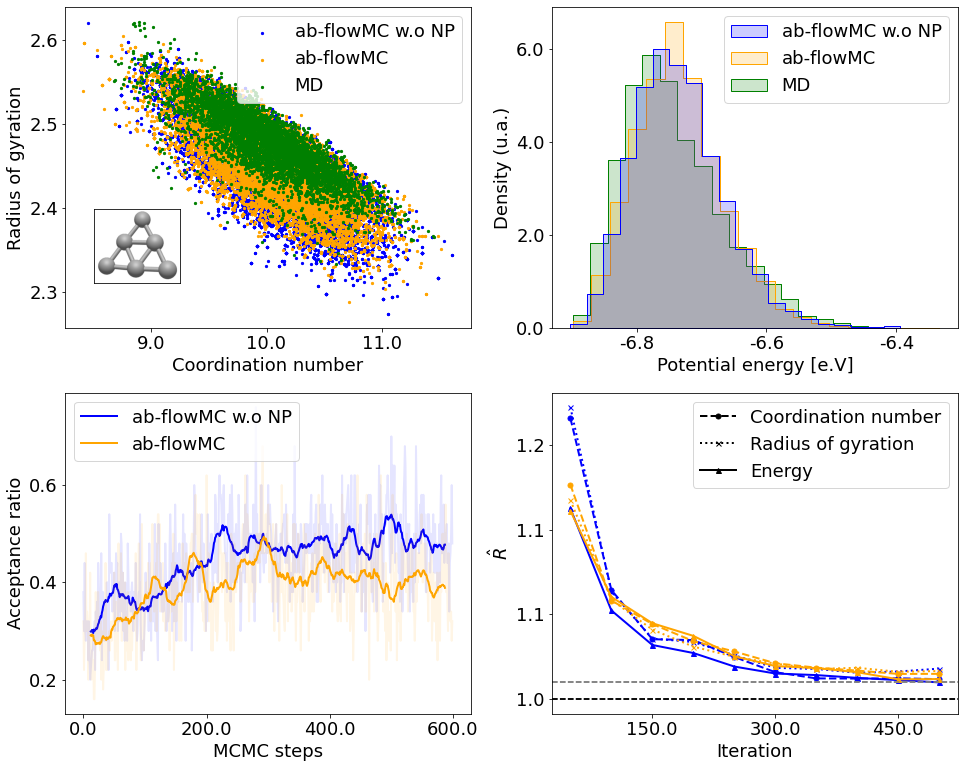

In [14]:
plot_figure_single_isomer_slide(plot_data_is0, color_keys, scale)

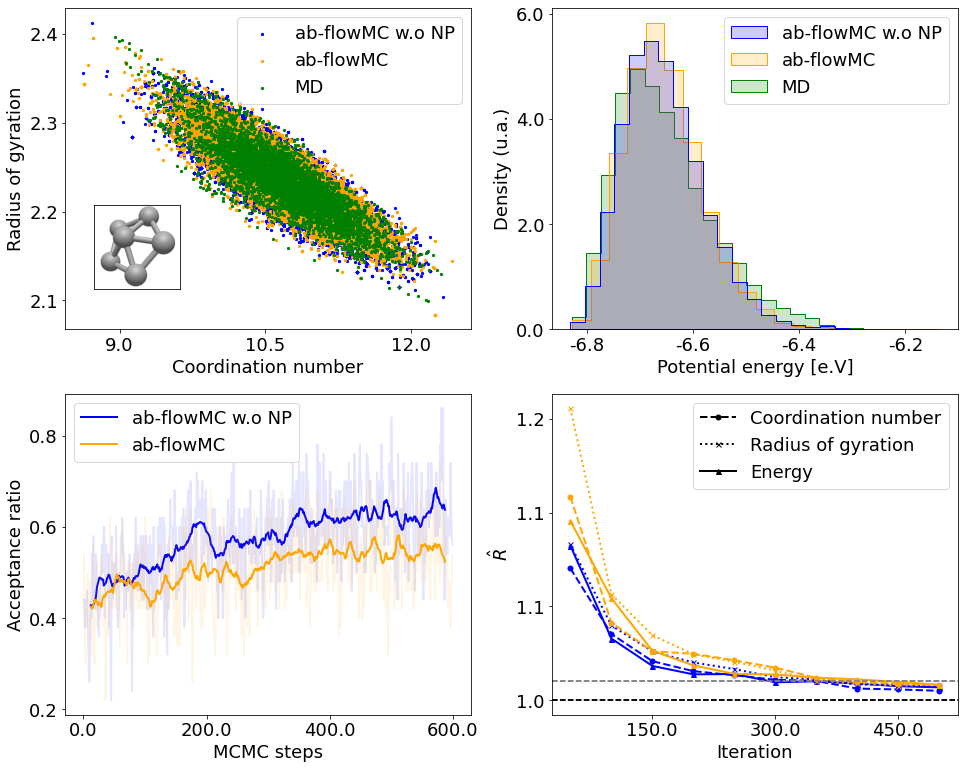

In [15]:
plot_figure_single_isomer_slide(plot_data_is1, color_keys, scale)

In [16]:
keys = ['ab-flowMM w.o NP', 'ab-flowMM']
color_keys = dict(zip(keys, ['blue', 'orange']))
mcmcs = {new_key: load_pickle_file('mcmcs_sims.pkl', get_project_path() + '/data_for_plots')[old_key] for old_key, new_key in zip(['Ab-initio flow MC w.o NP Mixture Model', 
        'Ab-initio flow MC Mixture Model'], keys)}

In [17]:
from flonacomldft.models.mixture import Mixture

In [18]:
weights = torch.tensor([0.75, 0.25]).detach()
mixture_models = {}
for key, adaptives in zip(keys, [adaptives_dft, adaptives_mlp]):
    flow_models = []
    for i in range(2):
        flow_models.append(adaptives[i]['dict_flows_training'][-1][0]['model'])
    mixture_model = Mixture(flow_models, weights)
    mixture_models[key] = mixture_model

In [19]:
from flonacomldft.internal_coordinates import Coordinates_mapping

In [20]:
def get_data_proposals(n_samples, mixture_model):
    samples, isomers = mixture_model.sample(n_samples, return_mus=True)
    target_log_prob = lambda x: -mixture_model.nll(x)
    coord_mapping = Coordinates_mapping()
    log_prob = torch.cat([target_log_prob(samples)[isomers == i] for i in range(2)]).reshape(-1, 1)
    cvs = torch.cat([ coord_mapping.get_collective_variables_from_real_centered(samples[isomers==i], isomer=i) for i in range(2)])
    data = pd.DataFrame(torch.cat((cvs, torch.exp(log_prob)), dim=1).detach(), columns=['Radius of gyration', 'Coordination number', 'Prob'])
    return data

In [21]:
data_proposals = {key: get_data_proposals(1000, mixture_models[key]) for key in keys}

In [22]:
from flonacomldft.models.mixture import Mixture


In [23]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in keys}

In [24]:
cvs_mcmcs = {new_key: load_pickle_file('cvs_mcmcs.pkl', get_project_path() + '/data_for_plots')[old_key] for old_key, new_key in zip(['Ab-initio flow MC w.o NP Mixture Model', 
        'Ab-initio flow MC Mixture Model'], keys)}

In [25]:
time_sims = {}

for key in mcmcs.keys():
    time_sims[key] = mcmcs[key]['time_mcmc']
    min_time = min(time_sims[key])
    time_sims[key] = torch.tensor([t - min_time for t in time_sims[key]]).detach()
    time_sims[key] = time_sims[key] / 3600

In [26]:
rhat = {}

for key in keys:
    xss = torch.cat((cvs_mcmcs[key], 
                us[key].reshape(1000, 50, 1)), 
                dim=2).detach().numpy().transpose(1, 0, 2)

    rhat[key] = R_hat(xss, labels=['Coordination number', 'Radius of gyration', 'Energy'])

In [27]:
isomers = {key: mcmcs[key]['isomers'] for key in keys}

In [28]:
isomer_colors = {0: 'cyan', 1: 'salmon'}

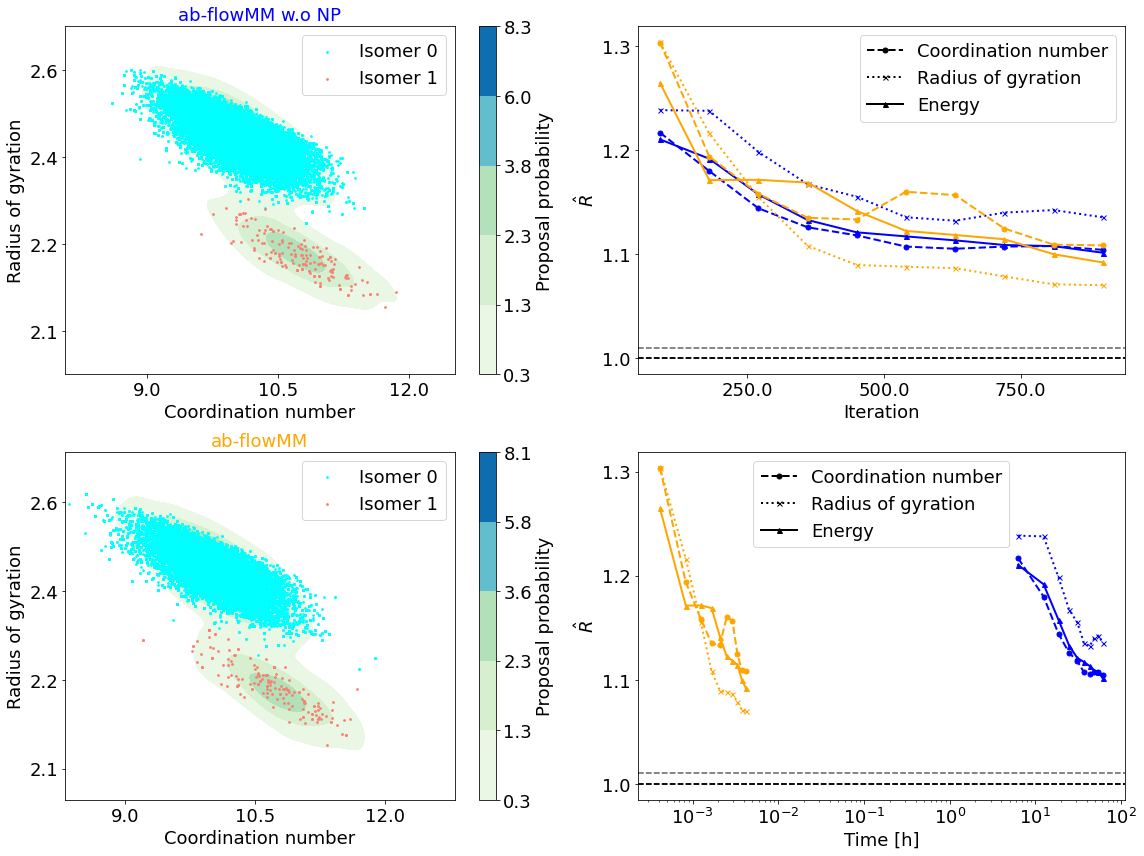

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
formatter = FormatStrFormatter('%.1f')
# PLOT collective variables
for i, key in enumerate(cvs_mcmcs.keys()):
    sns.kdeplot(data=data_proposals[key], x='Radius of gyration', y='Coordination number', 
                fill=True, cmap='GnBu', ax=axs[i, 0], cbar=True, 
                levels=6,  cbar_kws={'label': 'Proposal probability', 'format': formatter})
    for k in range(2):
        axs[i, 0].scatter(cvs_mcmcs[key][isomers[key]==k][:, 0].flatten().detach(), 
                cvs_mcmcs[key][isomers[key]==k][:, 1].flatten().detach(), 
                s=3*scale, 
                color=isomer_colors[k], 
                label='Isomer {:d}'.format(k))
    axs[i, 0].set_xlabel('Coordination number')
    axs[i, 0].set_ylabel('Radius of gyration')
    axs[i, 0].legend()

markers = ['o', 'x', '^']
linestyles = ['dashed', 'dotted', '-']

for i, key in enumerate(rhat.keys()):
    axs[i][0].set_title(key, color=color_keys[key])

for key in rhat.keys():
        for i in range(rhat[key][0].shape[-1]):
            axs[0][1].plot(rhat[key][1], 
                            rhat[key][0][:, i], 
                            linestyle=linestyles[i], 
                            marker=markers[i],
                            markersize=5*scale,
                            linewidth=2*scale,
                            color=color_keys[key], 
                            label=rhat[key][2][i])

            

            axs[1][1].plot(time_sims[key][rhat[key][1]],
                            rhat[key][0][:, i],
                            linestyle=linestyles[i], 
                            marker=markers[i],
                            markersize=5*scale,
                            linewidth=2*scale,
                            color=color_keys[key], 
                            label=rhat[key][2][i])
        
        axs[1][1].set_xlabel('Time [h]')
        axs[1][1].set_ylabel(r'$\hat{R}$')
        axs[1][1].axhline(1, c='k', ls='--')
        axs[1][1].axhline(1.01, c='grey', ls='--')
        axs[1][1].set_xscale('log')


        axs[0][1].axhline(1, c='k', ls='--')
        axs[0][1].axhline(1.01, c='grey', ls='--')
        axs[0][1].set_xlabel('Iteration')
        axs[0][1].set_ylabel(r'$\hat{R}$')

for ax in axs.ravel()[:-1]:
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

axs[1][1].yaxis.set_major_locator(plt.MaxNLocator(4))
#axs[1][1].xaxis.set_major_formatter(FormatStrFormatter('%e'))


for j in range(2):
    colors = ["k"]*3
    patches = [ axs[j][1].plot([],[], marker=markers[i], linestyle=linestyles[i], linewidth=2*scale, markersize=5*scale, color=colors[i], 
                label="{:s}".format(rhat[key][2][i]) )[0]  for i in range(len(rhat[key][2])) ]
    axs[j][1].legend(handles=patches)#, bbox_to_anchor=(0.5, 0.5), 
    
plt.tight_layout()

In [30]:
isomers[keys[1]].sum(dim=0)!=91

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True])

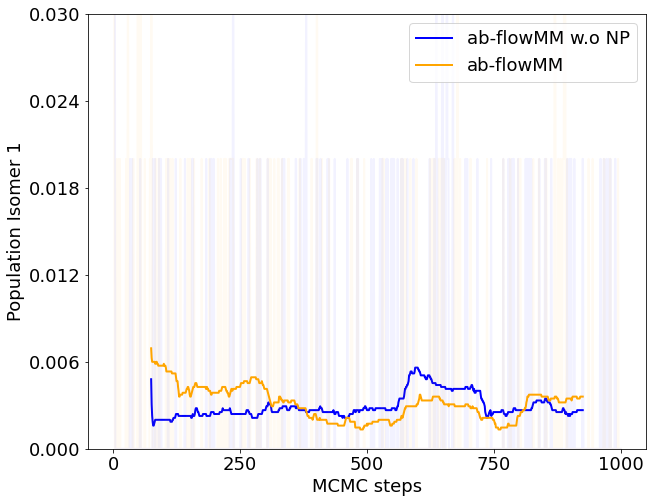

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
formatter = FormatStrFormatter('%.3f')
for key in keys:
    set_plot_sequential_data(isomers[key].mean(dim=1).detach(), 
        avg=True, 
        window_size=150, 
        ax=ax,
        linewidth=2,
        label=key, color=color_keys[key], alpha=0.05)

ax.set_xlabel('MCMC steps')
ax.set_ylabel('Population Isomer 1')
ax.legend()

ax.set_ylim(0, 0.03)

ax.xaxis.set_major_locator(plt.MaxNLocator(5))
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.yaxis.set_major_formatter(formatter)

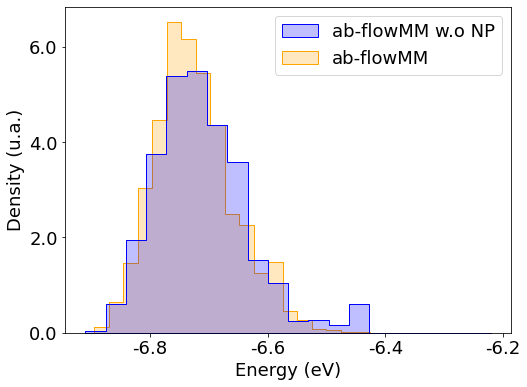

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
formatter = FormatStrFormatter('%.1f')
# PLOT energies
plot_energy_histogram(us, ax=ax, palette=color_keys, bins=20, element='step')

ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)